# The Forward Model: SFH → SED → Photometry

Every SED-fitting code has a forward model that maps physical
parameters to predicted observations.  In diffsed, this forward model
is **fully differentiable** — JAX computes exact gradients through the
entire pipeline, which is the key enabler for high-dimensional
inference.

```
SFR(t) → weights wᵢ → Σ wᵢ Lᵢ(SSP) → dust A(λ,t) → redshift → filters → fᵥ
```

**By the end you will understand:**

1. How stellar population synthesis builds a galaxy spectrum from SSPs
2. How dust attenuation reddens the SED (Charlot & Fall 2000)
3. How filter convolution produces broadband photometry
4. Which parameters affect which bands (the Jacobian)
5. Key degeneracies in SED fitting

In [1]:
import os
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from diffsed import (
    Model, ParamSpec, Uniform, Fixed,
    load_ssp_data, load_filter_set,
)
from diffsed.models.sps.dsps_wrapper import (
    compute_csp_weights, compute_csp_sed, interpolate_metallicity,
)
from diffsed.models.dust.charlot_fall import charlot_fall
from diffsed.models.sfh.mean_sfh import double_powerlaw

import sys; sys.path.insert(0, ".")
import sys; sys.path.insert(0, "..")
from _plot_style import (setup_style, COLORS, SDSS_WAVE_EFF, SDSS_BAND_NAMES,
                          SDSS_BAND_COLORS, SPECTRAL_FEATURES)
setup_style()

FIG_DIR = "../notebook_figures"
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"T02_{name}.png"),
                bbox_inches="tight", dpi=72)

ssp_data = load_ssp_data(
    "../../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filter_names = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
filter_waves, filter_trans, filter_curves = load_filter_set(filter_names)

wave = np.array(ssp_data.ssp_wave)
lg_age_gyr = np.array(ssp_data.ssp_lg_age_gyr)
print(f"SSP grid: {len(ssp_data.ssp_lgmet)} Z × "
      f"{len(lg_age_gyr)} ages × {len(wave)} λ")

SSP grid: 15 Z × 93 ages × 5994 λ


## 1. Simple Stellar Populations

An SSP is a single instantaneous burst of star formation at one age
and one metallicity.  Its spectrum encodes stellar evolution: hot young
O/B stars dominate the UV, intermediate-age A/F stars power the
optical, and cool red giants produce most of the NIR luminosity.

| Feature | Wavelength | Origin |
|---------|-----------|--------|
| Lyman limit | 912 Å | Hydrogen ionisation edge |
| D4000 | ~4000 Å | Metal-line blanketing + Balmer limit |
| Hβ | 4861 Å | Hydrogen recombination |
| Hα (+[NII]) | 6563 Å | Ionised gas around young stars |
| Ca II triplet | ~8500 Å | Cool giant atmospheres |

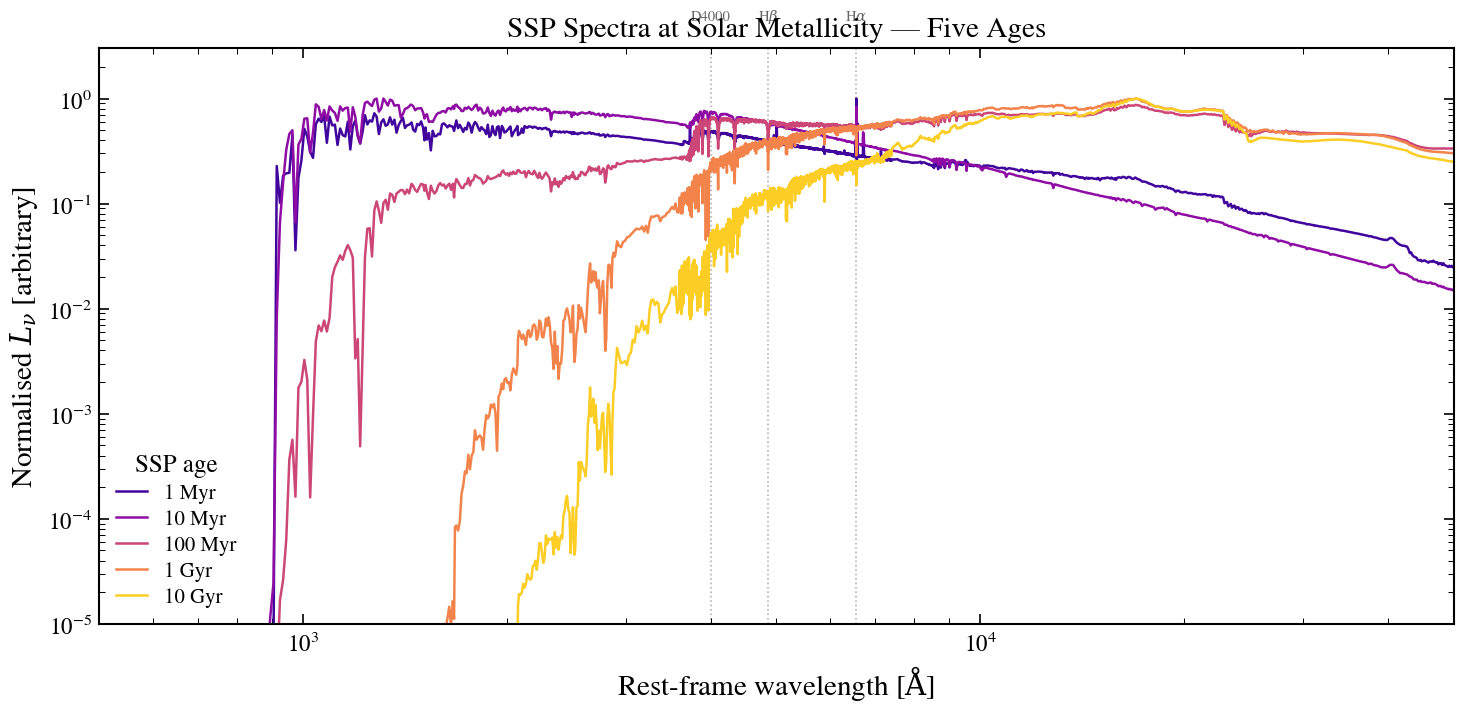

In [2]:
target_ages_gyr = [1e-3, 1e-2, 1e-1, 1.0, 10.0]
labels = ["1 Myr", "10 Myr", "100 Myr", "1 Gyr", "10 Gyr"]
colors_age = plt.cm.plasma(np.linspace(0.1, 0.9, len(target_ages_gyr)))

met_idx = int(np.argmin(np.abs(np.array(ssp_data.ssp_lgmet))))
ssp_flux_solar = ssp_data.ssp_flux[met_idx]

fig, ax = plt.subplots(figsize=(10, 5))
for age_gyr, label, color in zip(target_ages_gyr, labels, colors_age):
    idx = int(np.argmin(np.abs(10**lg_age_gyr - age_gyr)))
    flux = np.array(ssp_flux_solar[idx])
    flux_norm = flux / np.max(flux[wave > 1000])
    ax.plot(wave, flux_norm, lw=1.2, color=color, label=label)

for name, wl in {"D4000": 4000, r"H$\alpha$": 6563, r"H$\beta$": 4861}.items():
    ax.axvline(wl, color="0.7", ls=":", lw=0.8, zorder=0)
    ax.text(wl, 1.05, name, ha="center", fontsize=7, color="0.4",
            transform=ax.get_xaxis_transform())

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(500, 5e4); ax.set_ylim(1e-5, 3)
ax.set_xlabel(r"Rest-frame wavelength [$\mathrm{\AA}$]")
ax.set_ylabel(r"Normalised $L_\nu$ [arbitrary]")
ax.set_title("SSP Spectra at Solar Metallicity — Five Ages")
ax.legend(title="SSP age", loc="lower left")
fig.tight_layout(); savefig(fig, "ssp_spectra"); plt.show()

## 2. The Composite Stellar Population

A real galaxy forms stars continuously.  The observed spectrum is the
SFH-weighted integral over all SSP ages:

$$L_\nu(\lambda) = \sum_i w_i \cdot L_\nu^{\rm SSP}(\lambda, t_i)$$

where $w_i = \mathrm{SFR}(t_i)\,\Delta t_i$ is the stellar mass
formed in age bin $i$.

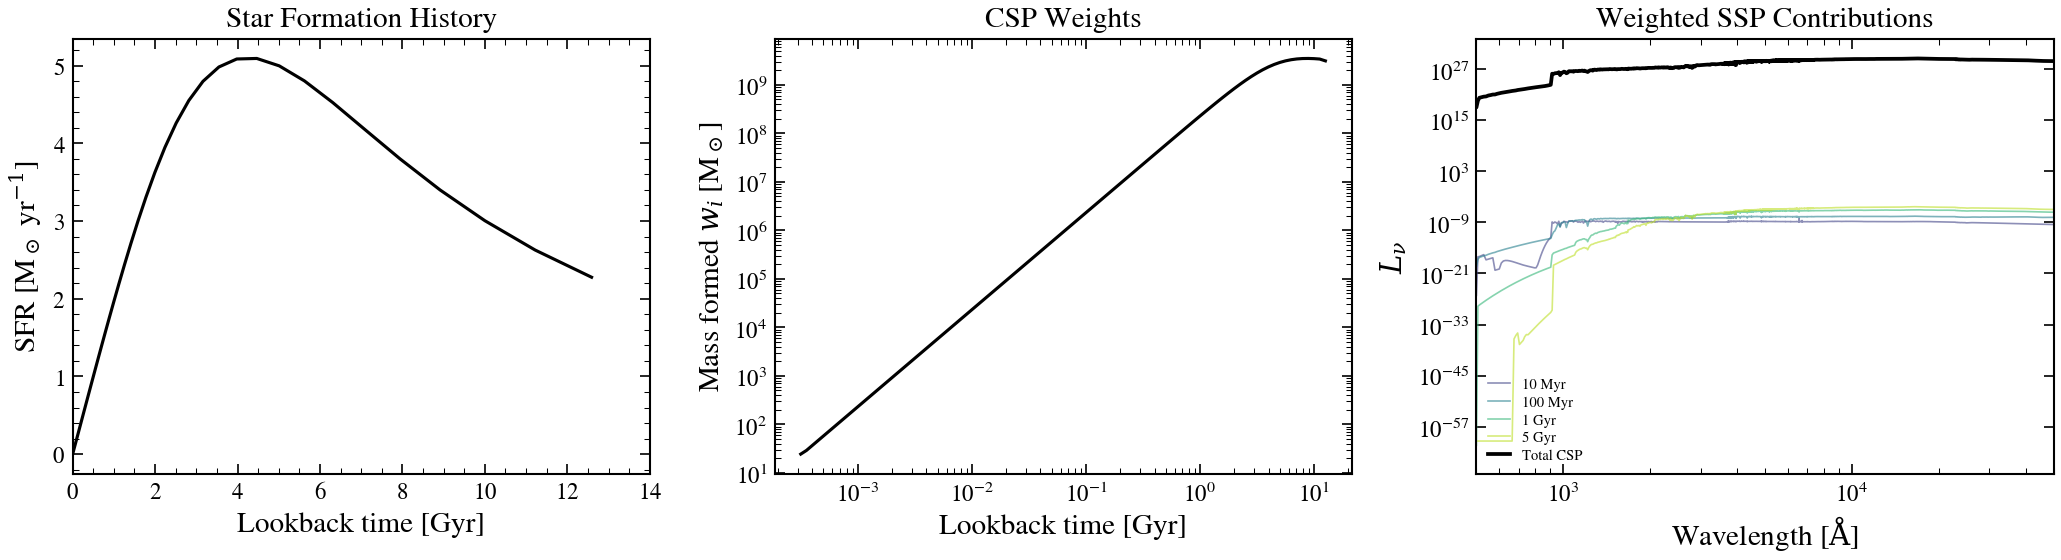

In [3]:
ssp_ages_yr = 10**(lg_age_gyr + 9)
sfr = double_powerlaw(ssp_ages_yr, 1.5, 1.0, 5e9, 10.0)
weights = compute_csp_weights(jnp.array(sfr), jnp.array(ssp_ages_yr))
ssp_flux_at_Z = interpolate_metallicity(ssp_data.ssp_flux, ssp_data.ssp_lgmet,
                                         log_z=-1.848)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ssp_ages_yr / 1e9, sfr, "k-", lw=1.5)
axes[0].set_xlabel("Lookback time [Gyr]"); axes[0].set_ylabel(r"SFR [M$_\odot$ yr$^{-1}$]")
axes[0].set_title("Star Formation History"); axes[0].set_xlim(0, 14)

axes[1].plot(ssp_ages_yr / 1e9, np.array(weights), "k-", lw=1.5)
axes[1].set_xlabel("Lookback time [Gyr]"); axes[1].set_ylabel(r"Mass formed $w_i$ [M$_\odot$]")
axes[1].set_title("CSP Weights"); axes[1].set_xscale("log"); axes[1].set_yscale("log")

highlight_ages = [1e-2, 1e-1, 1.0, 5.0]
highlight_labels = ["10 Myr", "100 Myr", "1 Gyr", "5 Gyr"]
for age_gyr, lab, col in zip(highlight_ages, highlight_labels,
                              plt.cm.viridis(np.linspace(0.2, 0.9, 4))):
    idx = int(np.argmin(np.abs(10**lg_age_gyr - age_gyr)))
    axes[2].plot(wave, float(weights[idx]) * np.array(ssp_flux_at_Z[idx]),
                 lw=0.8, color=col, alpha=0.6, label=lab)

no_dust = jnp.ones_like(ssp_flux_at_Z)
csp_sed = compute_csp_sed(weights, ssp_flux_at_Z, no_dust)
axes[2].plot(wave, np.array(csp_sed), "k-", lw=1.8, label="Total CSP")
axes[2].set_xscale("log"); axes[2].set_yscale("log"); axes[2].set_xlim(500, 5e4)
axes[2].set_xlabel(r"Wavelength [$\mathrm{\AA}$]")
axes[2].set_ylabel(r"$L_\nu$"); axes[2].set_title("Weighted SSP Contributions")
axes[2].legend(fontsize=7, loc="lower left")
fig.tight_layout(); savefig(fig, "csp_assembly"); plt.show()

## 3. Dust Attenuation: Charlot & Fall (2000)

Dust grains absorb and scatter UV/optical photons.  The two-component
model applies:

- **Birth cloud** ($\hat\tau_{V,1}$) — affects only young stars
  ($t_{\rm age} < 10$ Myr) still embedded in their natal cloud.
- **Diffuse ISM** ($\hat\tau_{V,2}$) — affects all stars.

The effective optical depth is:

$$\tau_\lambda(t) = \bigl[w(t)\,\hat\tau_{V,1} + \hat\tau_{V,2}\bigr] \left(\frac{\lambda}{5500\,\mathrm{\AA}}\right)^n$$

with a smooth sigmoid transition $w(t)$ around 10 Myr (differentiable
replacement for the original step function).

W0316 02:58:12.076674 5987039 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


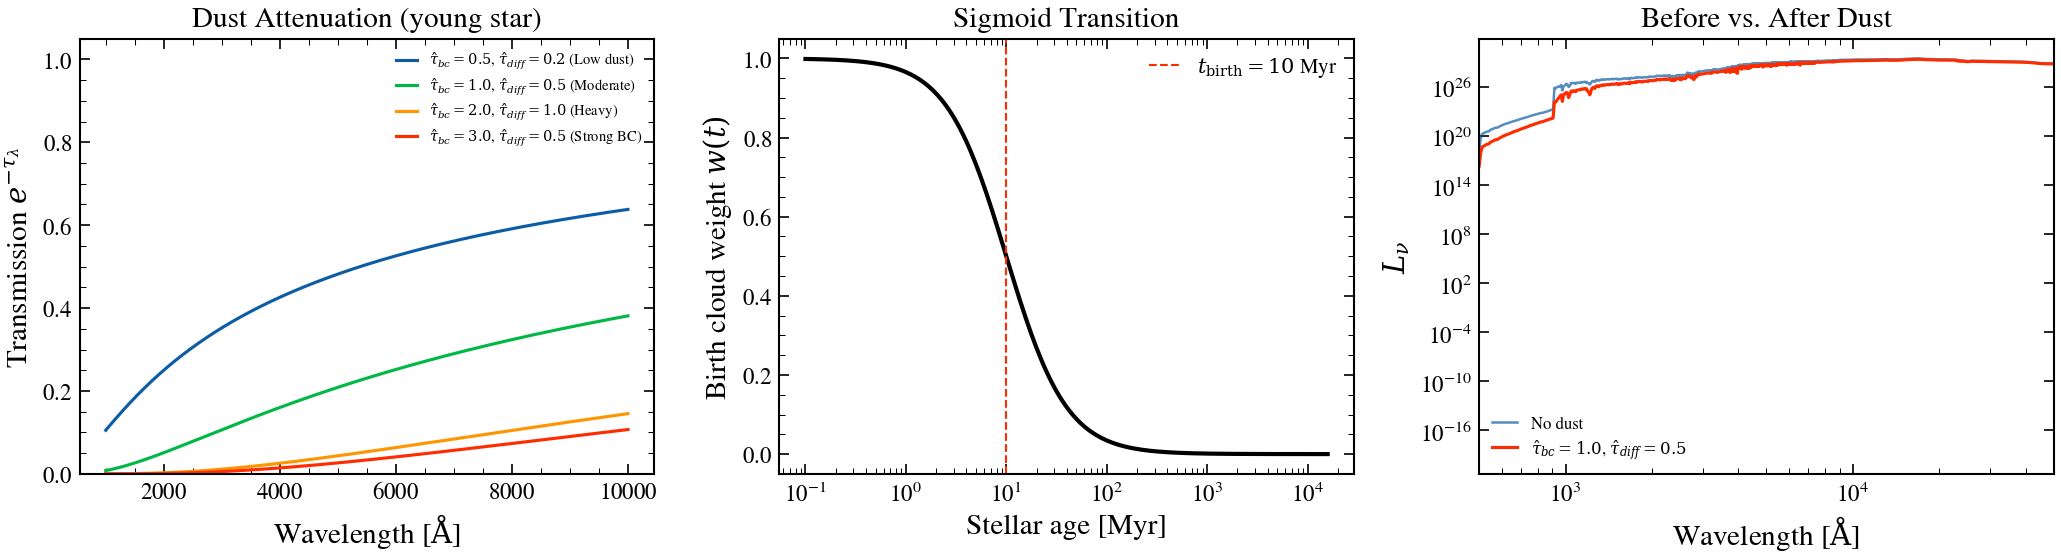

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

wave_plot = np.linspace(1000, 10000, 500)
configs = [(0.5, 0.2, "Low dust"), (1.0, 0.5, "Moderate"),
           (2.0, 1.0, "Heavy"), (3.0, 0.5, "Strong BC")]

ax = axes[0]
for tau_bc, tau_diff, label in configs:
    atten = charlot_fall(jnp.array(wave_plot), jnp.array([1e6]),
                         tau_v1=tau_bc, tau_v2=tau_diff)
    ax.plot(wave_plot, np.array(atten[0]), lw=1.5,
            label=rf"$\hat\tau_{{bc}}={tau_bc}$, $\hat\tau_{{diff}}={tau_diff}$ ({label})")
ax.set_xlabel(r"Wavelength [$\mathrm{\AA}$]"); ax.set_ylabel(r"Transmission $e^{-\tau_\lambda}$")
ax.set_title("Dust Attenuation (young star)"); ax.legend(fontsize=7); ax.set_ylim(0, 1.05)

ax = axes[1]
ages_plot = np.logspace(5, 10.2, 200)
log_age = np.log10(ages_plot)
w_t = 1.0 / (1.0 + np.exp(-(-(log_age - 7.0) / 0.3)))
ax.plot(ages_plot / 1e6, w_t, "k-", lw=2)
ax.axvline(10.0, color="C3", ls="--", lw=1, label=r"$t_{\rm birth}=10$ Myr")
ax.set_xscale("log"); ax.set_xlabel("Stellar age [Myr]")
ax.set_ylabel(r"Birth cloud weight $w(t)$"); ax.set_title("Sigmoid Transition")
ax.legend(); ax.set_ylim(-0.05, 1.05)

ax = axes[2]
csp_nodust = compute_csp_sed(weights, ssp_flux_at_Z, no_dust)
dust_atten = charlot_fall(jnp.array(wave), jnp.array(ssp_ages_yr),
                          tau_v1=1.0, tau_v2=0.5)
csp_dusty = compute_csp_sed(weights, ssp_flux_at_Z, dust_atten)
ax.plot(wave, np.array(csp_nodust), lw=1.2, color="C0", label="No dust", alpha=0.7)
ax.plot(wave, np.array(csp_dusty), lw=1.5, color="C3", label=r"$\hat\tau_{bc}=1.0$, $\hat\tau_{diff}=0.5$")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(500, 5e4)
ax.set_xlabel(r"Wavelength [$\mathrm{\AA}$]"); ax.set_ylabel(r"$L_\nu$")
ax.set_title("Before vs. After Dust"); ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig, "dust_attenuation"); plt.show()

## 4. Redshift and Filter Convolution

The rest-frame SED is shifted to the observer frame:

$$f_b = \frac{(1+z)}{4\pi d_L^2} \frac{\int L_\nu^{\rm att}(\lambda/(1+z))\, T_b(\lambda)\,\lambda\,d\lambda}{\int T_b(\lambda)\,\lambda\,d\lambda}$$

The filter transmission curves $T_b(\lambda)$ define which portion of
the SED each band measures.

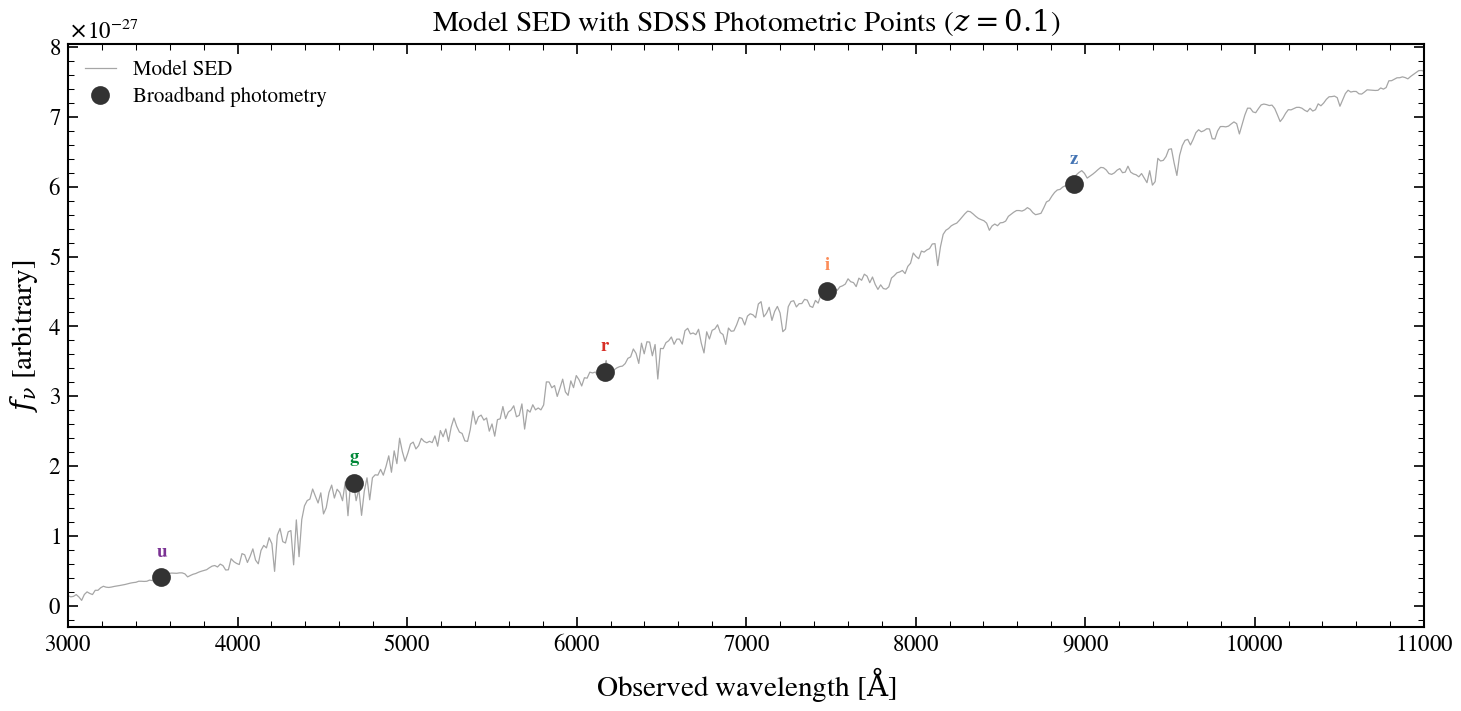

In [5]:
# Use the high-level API for a clean demonstration
spec = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0), sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0), sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Fixed(0.0), psd_tau_myr=Fixed(50.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0), dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7), redshift=Fixed(0.1), stochastic=False,
)
model = Model(spec, ssp_data, filters=(filter_waves, filter_trans, filter_curves))

params = dict(sfh_alpha=1.5, sfh_beta=1.0, sfh_tau_peak_gyr=5.0,
              sfh_peak_sfr=10.0, met_logzsol=-0.3,
              dust_tau_bc=0.5, dust_tau_diff=0.3)

# Full SED + photometric points
wave_obs = jnp.linspace(3000, 11000, 500)  # observed wavelengths
sed = model.predict_spectrum(params, wave_obs)
phot = model.predict_photometry(params)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.array(wave_obs), np.array(sed), color="0.5", lw=0.6, alpha=0.7,
        label="Model SED")
ax.errorbar(SDSS_WAVE_EFF, np.array(phot), fmt="o", ms=8,
            color=COLORS["data"], zorder=5, label="Broadband photometry")
for i, (bn, bc) in enumerate(zip(SDSS_BAND_NAMES, SDSS_BAND_COLORS)):
    ax.annotate(bn, (SDSS_WAVE_EFF[i], float(phot[i])),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color=bc, fontweight="bold")
ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]")
ax.set_ylabel(r"$f_\nu$ [arbitrary]")
ax.set_title("Model SED with SDSS Photometric Points ($z=0.1$)")
ax.set_xlim(3000, 11000); ax.legend()
fig.tight_layout(); savefig(fig, "sed_with_photometry"); plt.show()

## 5. The Jacobian: What Constrains What

Because the forward model is differentiable, we can compute
$\partial f_b / \partial \theta_k$ for every band $b$ and parameter
$\theta_k$.  This Jacobian reveals which observations constrain which
parameters — and where degeneracies lurk.

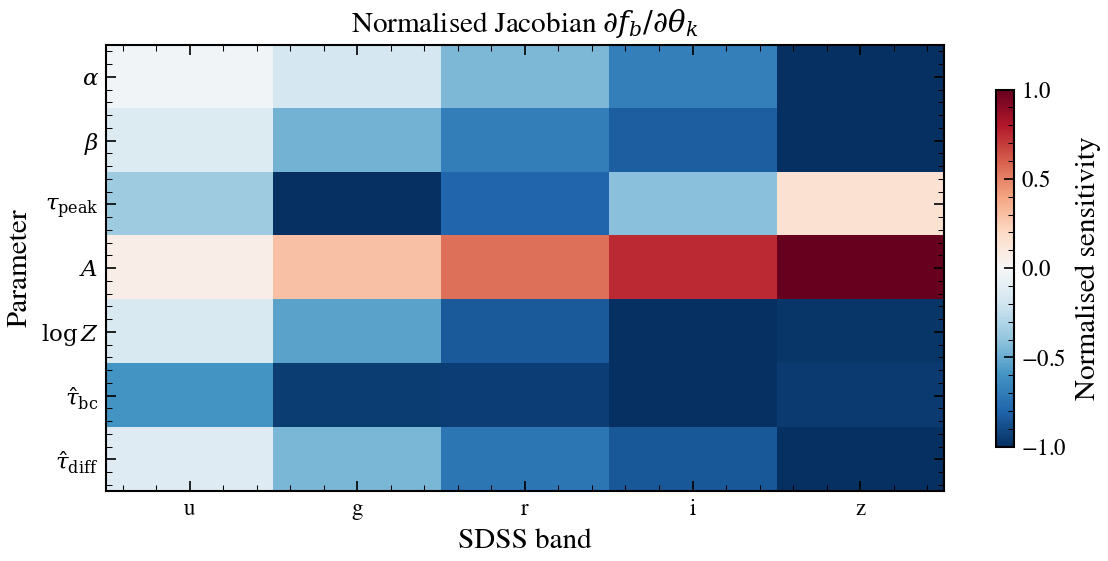

In [6]:
param_names = ["sfh_alpha", "sfh_beta", "sfh_tau_peak_gyr", "sfh_peak_sfr",
               "met_logzsol", "dust_tau_bc", "dust_tau_diff"]
param_labels = [r"$\alpha$", r"$\beta$", r"$\tau_{\rm peak}$", "$A$",
                r"$\log Z$", r"$\hat\tau_{\rm bc}$", r"$\hat\tau_{\rm diff}$"]

# Compute Jacobian via JAX
def photometry_fn(param_vec):
    p = {k: param_vec[i] for i, k in enumerate(param_names)}
    return model.predict_photometry(p)

param_vec = jnp.array([params[k] for k in param_names])
jac = jax.jacobian(photometry_fn)(param_vec)  # (n_bands, n_params)
jac_np = np.array(jac)

# Normalise each column by parameter scale for display
scales = np.abs(jac_np).max(axis=0, keepdims=True)
scales[scales == 0] = 1
jac_norm = jac_np / scales

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(jac_norm.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(SDSS_BAND_NAMES)
ax.set_yticks(range(len(param_labels))); ax.set_yticklabels(param_labels)
ax.set_xlabel("SDSS band"); ax.set_ylabel("Parameter")
ax.set_title(r"Normalised Jacobian $\partial f_b / \partial \theta_k$")
fig.colorbar(im, ax=ax, shrink=0.8, label="Normalised sensitivity")
fig.tight_layout(); savefig(fig, "jacobian_heatmap"); plt.show()

## Summary

The forward model pipeline is:

1. **SFH → weights**: double power law (+ GP) determines how much
   mass formed at each age.
2. **Weights × SSPs → CSP**: sum over age-weighted simple stellar
   populations at the chosen metallicity.
3. **Dust → attenuated CSP**: Charlot & Fall two-component model
   reddens the SED, affecting young stars more than old.
4. **Redshift + filters → photometry**: observer-frame flux through
   broadband filters.

Every step is a pure JAX function with exact gradients.  The Jacobian
reveals the information content of each band.

**Next:** [T03 — Inference](T03_inference.ipynb) shows how the five
inference methods explore the posterior of this forward model.